In [1]:
import pandas as pd
import os
import numpy as np

In [2]:
area_error_df  = pd.read_csv('SF_bias_nodes.csv')

In [3]:
# reclassify the areas into four quantitle based on quantiles
def classify_area_quantiles(area_series, nbins=4):
    quantiles = np.linspace(0, 1, nbins + 1)
    bins = area_series.quantile(quantiles).values
    # Ensure unique bin edges
    bins = np.unique(bins)
    labels = [f'D{i+1}' for i in range(len(bins)-1)]
    return pd.cut(area_series, bins=bins, labels=labels, include_lowest=True)

area_error_df['car_area_quantile'] = classify_area_quantiles(area_error_df['car_area'], nbins=10)
area_error_df['road_area_quantile'] = classify_area_quantiles(area_error_df['road_area'], nbins=10)
area_error_df['skew_confidence_quantile'] = classify_area_quantiles(area_error_df['skew_confidence'], nbins=10)
area_error_df['distance_closest_building_quantile'] = classify_area_quantiles(area_error_df['distance_closest_building'], nbins=10)

area_error_df

,skew_confidence,distance_closest_building,road_area,car_area,car_area_quantile,road_area_quantile,abs_slope_diff_huber,skew_confidence_quantile,distance_closest_building_quantile
0,15,12.148115,227392.5,182973.5,D10,D7,0.020397,D4,D9
1,32,12.105746,239359.5,43254.0,D4,D7,0.600579,D6,D9
2,23,8.941638,170013.0,81459.0,D6,D4,2.035226,D5,D3
3,23,10.911528,182650.0,92244.5,D6,D4,0.001387,D5,D7
4,19,18.922676,274582.0,77330.0,D6,D9,0.829100,D4,D10
...,...,...,...,...,...,...,...,...,...
8888,4,9.205448,179135.0,68560.0,D5,D4,1.336538,D1,D4
8889,19,10.774572,197539.0,152915.5,D9,D5,0.431492,D4,D7
8890,80,7.831181,137742.0,139975.5,D9,D2,1.132835,D9,D2
8891,123,7.225053,162460.0,146080.0,D9,D3,0.125724,D10,D2


In [4]:
cls_labels = ['D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10']

/var/folders/7_/kysgxgvn5h3680yrj7dky38w0000gn/T/ipykernel_31500/159500654.py:15: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = area_error_df.pivot_table(index='car_area_quantile', columns='road_area_quantile', values='abs_slope_diff_huber', aggfunc='mean')
/var/folders/7_/kysgxgvn5h3680yrj7dky38w0000gn/T/ipykernel_31500/159500654.py:18: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  count_data = area_error_df.pivot_table(index='car_area_quantile', columns='road_area_quantile', values='abs_slope_diff_huber', aggfunc='count')
/var/folders/7_/kysgxgvn5h3680yrj7dky38w0000gn/T/ipykernel_31500/159500654.py:77: FutureWarning: The default of observed=False 

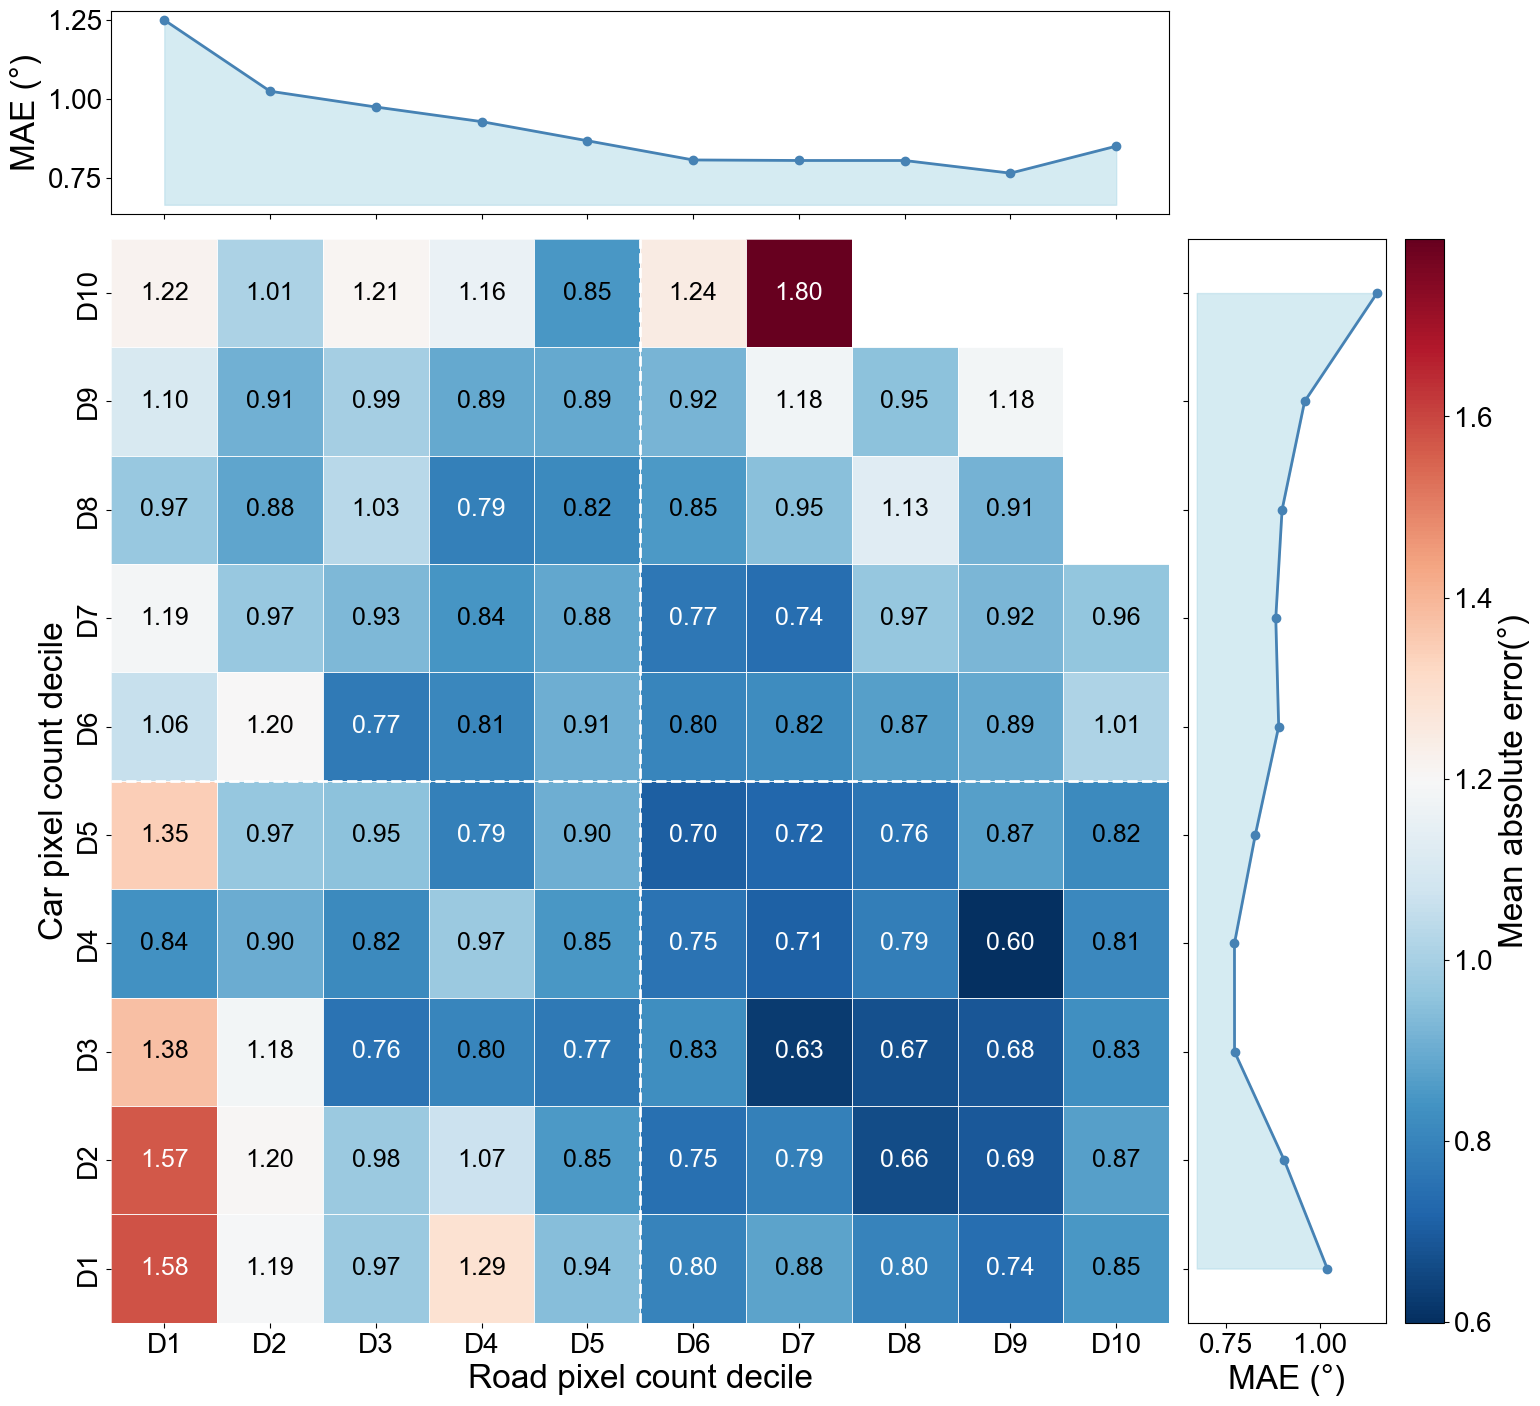

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

label_fontsize = 24
tick_fontsize = 20
annotation_fontsize = 18
plt.rcParams.update({
    'font.family': 'Arial',
})

# create a heatmap to show the absolute slope error by car_area and road_area using seaborn


# pivot the dataframe to create a matrix for heatmap
heatmap_data = area_error_df.pivot_table(index='car_area_quantile', columns='road_area_quantile', values='abs_slope_diff_huber', aggfunc='mean')

# count the number of samples in each cell
count_data = area_error_df.pivot_table(index='car_area_quantile', columns='road_area_quantile', values='abs_slope_diff_huber', aggfunc='count')

# if the count<3, set the heatmap value to NaN
heatmap_data[count_data < 3] = np.nan

# Create figure with subplots for main heatmap and marginal plots
fig = plt.figure(figsize=(20, 20))
gs = fig.add_gridspec(3, 4, width_ratios=[1.5, 8, 1.5, 0.3], height_ratios=[1.5, 8, 1.5], 
                      hspace=0.05, wspace=0.05)

# Main heatmap
ax_main = fig.add_subplot(gs[1, 1])
im = sns.heatmap(heatmap_data, annot=False, fmt=".2f", cmap='RdBu_r', cbar=False, ax=ax_main)

ax_main.set_xlabel('Road pixel count decile', fontsize=label_fontsize)
ax_main.set_ylabel('Car pixel count decile', fontsize=label_fontsize)
ax_main.tick_params(axis='both', labelsize=tick_fontsize)

def text_color(value):
    if np.isnan(value):
        return 'black'
    elif value < 0.8:
        return 'white'
    elif value > 1.5:
        return 'white'
    else:
        return 'black'

# set text annotations for each cell
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data.iloc[i, j]
        count = count_data.iloc[i, j]
        if not np.isnan(value):

            ax_main.text(j + 0.5, i + 0.5, f"{value:.2f}", 
                         ha='center', va='center', color=text_color(value), fontsize=annotation_fontsize)

# each cell add the white border
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        rect = plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='white', lw=0.5)
        ax_main.add_patch(rect)

# reverse the y axis to have D1 at the bottom
ax_main.invert_yaxis()

# Colorbar in the dedicated space
cbar_ax = fig.add_subplot(gs[1, 3])
cbar = fig.colorbar(im.get_children()[0], cax=cbar_ax, orientation='vertical')
cbar.ax.tick_params(labelsize=tick_fontsize)
cbar.set_label('Mean absolute error(°)', fontsize=label_fontsize)

# add separation lines
ax_main.axhline(5, color='white', linewidth=2, linestyle='--')
ax_main.axvline(5, color='white', linewidth=2, linestyle='--')

# Top marginal plot
ax_top = fig.add_subplot(gs[0, 1], sharex=ax_main)
road_medians = area_error_df.groupby('road_area_quantile')['abs_slope_diff_huber'].mean()
# Ensure we have data for all quantiles and handle missing ones
road_x_positions = range(len(road_medians))
# for each position, add 0.5 to center the marker in the cell
road_x_positions = [x + 0.5 for x in road_x_positions]
ax_top.plot(road_x_positions, road_medians.values, 
           color='steelblue', linewidth=2, marker='o', markersize=6)
ax_top.fill_between(road_x_positions, 
                   [road_medians.min()-0.1]*len(road_medians), 
                   road_medians.values, 
                   color='lightblue', alpha=0.5)
ax_top.tick_params(axis='x', labelbottom=False)
ax_top.tick_params(axis='y', labelsize=tick_fontsize)
ax_top.set_ylabel('MAE (°)', fontsize=label_fontsize)

# Right marginal plot
ax_right = fig.add_subplot(gs[1, 2], sharey=ax_main)
car_medians = area_error_df.groupby('car_area_quantile')['abs_slope_diff_huber'].mean()
# Reverse the order to match inverted y-axis
car_y_positions = range(len(car_medians))
car_y_positions = [y + 0.5 for y in car_y_positions]
ax_right.plot(car_medians.values, car_y_positions,
             color='steelblue', linewidth=2, marker='o', markersize=6)
ax_right.fill_betweenx(car_y_positions, 
                      [min(car_medians.values)-0.1]*len(car_medians), 
                      car_medians.values, 
                      color='lightblue', alpha=0.5)
ax_right.tick_params(axis='y', labelleft=False)
ax_right.tick_params(axis='x', labelsize=tick_fontsize)
ax_right.set_xlabel('MAE (°)', fontsize=label_fontsize)

plt.tight_layout()
plt.show()


/var/folders/7_/kysgxgvn5h3680yrj7dky38w0000gn/T/ipykernel_31500/1000971061.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  count_data = area_error_df.pivot_table(index='skew_confidence_quantile', columns='distance_closest_building_quantile', values='abs_slope_diff_huber', aggfunc='count')
/var/folders/7_/kysgxgvn5h3680yrj7dky38w0000gn/T/ipykernel_31500/1000971061.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = area_error_df.pivot_table(index='skew_confidence_quantile', columns='distance_closest_building_quantile', values='abs_slope_diff_huber', aggfunc='mean')
/var/folders/7_/kysgxgvn5h3680yrj7dky38w0000gn/T/ipykernel_31500/1000971061.py:50

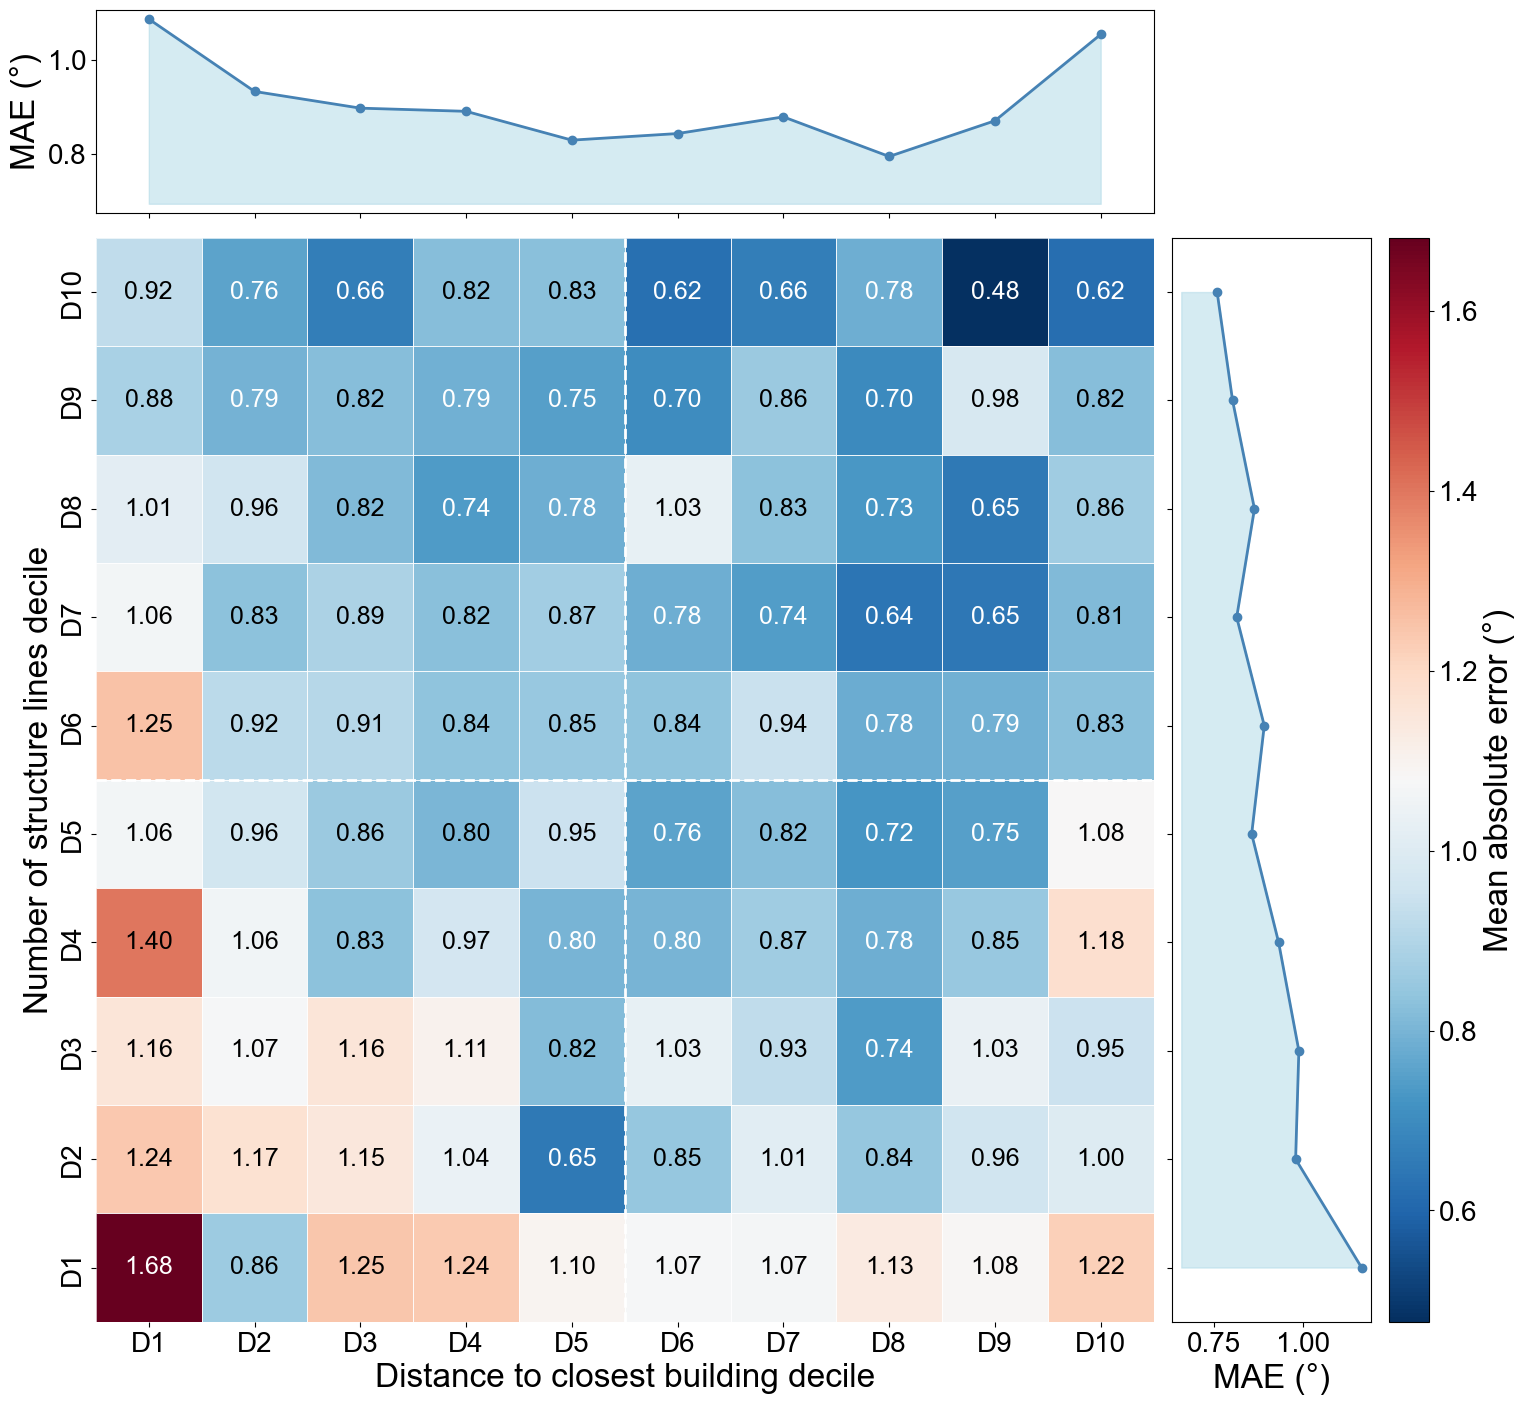

In [11]:

# count the number of samples in each cell
count_data = area_error_df.pivot_table(index='skew_confidence_quantile', columns='distance_closest_building_quantile', values='abs_slope_diff_huber', aggfunc='count')
heatmap_data = area_error_df.pivot_table(index='skew_confidence_quantile', columns='distance_closest_building_quantile', values='abs_slope_diff_huber', aggfunc='mean')
# if the count<3, set the heatmap value to NaN
heatmap_data[count_data < 3] = np.nan

# Create figure with subplots for main heatmap and marginal plots
fig = plt.figure(figsize=(20, 20))
gs = fig.add_gridspec(3, 4, width_ratios=[1.5, 8, 1.5, 0.3], height_ratios=[1.5, 8, 1.5], 
                      hspace=0.05, wspace=0.05)

# Main heatmap
ax_main = fig.add_subplot(gs[1, 1])
im = sns.heatmap(heatmap_data, annot=False, fmt=".2f", cmap='RdBu_r', cbar=False, ax=ax_main)

ax_main.set_xlabel('Distance to closest building decile', fontsize=label_fontsize)
ax_main.set_ylabel('Number of structure lines decile', fontsize=label_fontsize)
ax_main.tick_params(axis='both', labelsize=tick_fontsize)

# set text annotations for each cell
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data.iloc[i, j]
        count = count_data.iloc[i, j]
        if not np.isnan(value):
            ax_main.text(j + 0.5, i + 0.5, f"{value:.2f}", 
                         ha='center', va='center', color=text_color(value), fontsize=annotation_fontsize)

# reverse the y axis to have D1 at the bottom
ax_main.invert_yaxis()

# each cell add the white border
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        rect = plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='white', lw=0.5)
        ax_main.add_patch(rect)

# Colorbar in the dedicated space
cbar_ax = fig.add_subplot(gs[1, 3])
cbar = fig.colorbar(im.get_children()[0], cax=cbar_ax, orientation='vertical')
cbar.ax.tick_params(labelsize=tick_fontsize)
cbar.set_label('Mean absolute error (°)', fontsize=label_fontsize)

# add separation lines
ax_main.axhline(5, color='white', linewidth=2, linestyle='--')
ax_main.axvline(5, color='white', linewidth=2, linestyle='--')

# Top marginal plot
ax_top = fig.add_subplot(gs[0, 1], sharex=ax_main)
dist_medians = area_error_df.groupby('distance_closest_building_quantile')['abs_slope_diff_huber'].mean()

# Check if we have data and handle missing quantiles
if len(dist_medians) > 0:
    # Ensure we have data for all quantiles and handle missing ones
    dist_x_positions = range(len(dist_medians))
    # for each position, add 0.5 to center the marker in the cell
    dist_x_positions = [x + 0.5 for x in dist_x_positions]
    
    ax_top.plot(dist_x_positions, dist_medians.values, 
               color='steelblue', linewidth=2, marker='o', markersize=6)
    
    # Use robust min calculation for fill_between
    y_min = max(0, dist_medians.min() - 0.1)
    ax_top.fill_between(dist_x_positions, 
                       [y_min]*len(dist_medians), 
                       dist_medians.values, 
                       color='lightblue', alpha=0.5)

ax_top.tick_params(axis='x', labelbottom=False)
ax_top.tick_params(axis='y', labelsize=tick_fontsize)
ax_top.set_ylabel('MAE (°)', fontsize=label_fontsize)

# Right marginal plot
ax_right = fig.add_subplot(gs[1, 2], sharey=ax_main)
skew_medians = area_error_df.groupby('skew_confidence_quantile')['abs_slope_diff_huber'].mean()

# Check if we have data
if len(skew_medians) > 0:
    # Reverse the order to match inverted y-axis
    skew_y_positions = range(len(skew_medians))
    skew_y_positions = [y + 0.5 for y in skew_y_positions]

    ax_right.plot(skew_medians.values, skew_y_positions,
                 color='steelblue', linewidth=2, marker='o', markersize=6)
    
    # Use robust min calculation for fill_betweenx
    x_min = max(0, min(skew_medians.values) - 0.1)
    ax_right.fill_betweenx(skew_y_positions, 
                          [x_min]*len(skew_medians), 
                          skew_medians.values, 
                          color='lightblue', alpha=0.5)

ax_right.tick_params(axis='y', labelleft=False)
ax_right.tick_params(axis='x', labelsize=tick_fontsize)
ax_right.set_xlabel('MAE (°)', fontsize=label_fontsize)

plt.tight_layout()
plt.show()

/var/folders/7_/kysgxgvn5h3680yrj7dky38w0000gn/T/ipykernel_31500/4086967848.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  count_data = area_error_df.pivot_table(index='car_area_quantile', columns='distance_closest_building_quantile', values='abs_slope_diff_huber', aggfunc='count')
/var/folders/7_/kysgxgvn5h3680yrj7dky38w0000gn/T/ipykernel_31500/4086967848.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = area_error_df.pivot_table(index='car_area_quantile', columns='distance_closest_building_quantile', values='abs_slope_diff_huber', aggfunc='mean')
/var/folders/7_/kysgxgvn5h3680yrj7dky38w0000gn/T/ipykernel_31500/4086967848.py:50: FutureWarnin

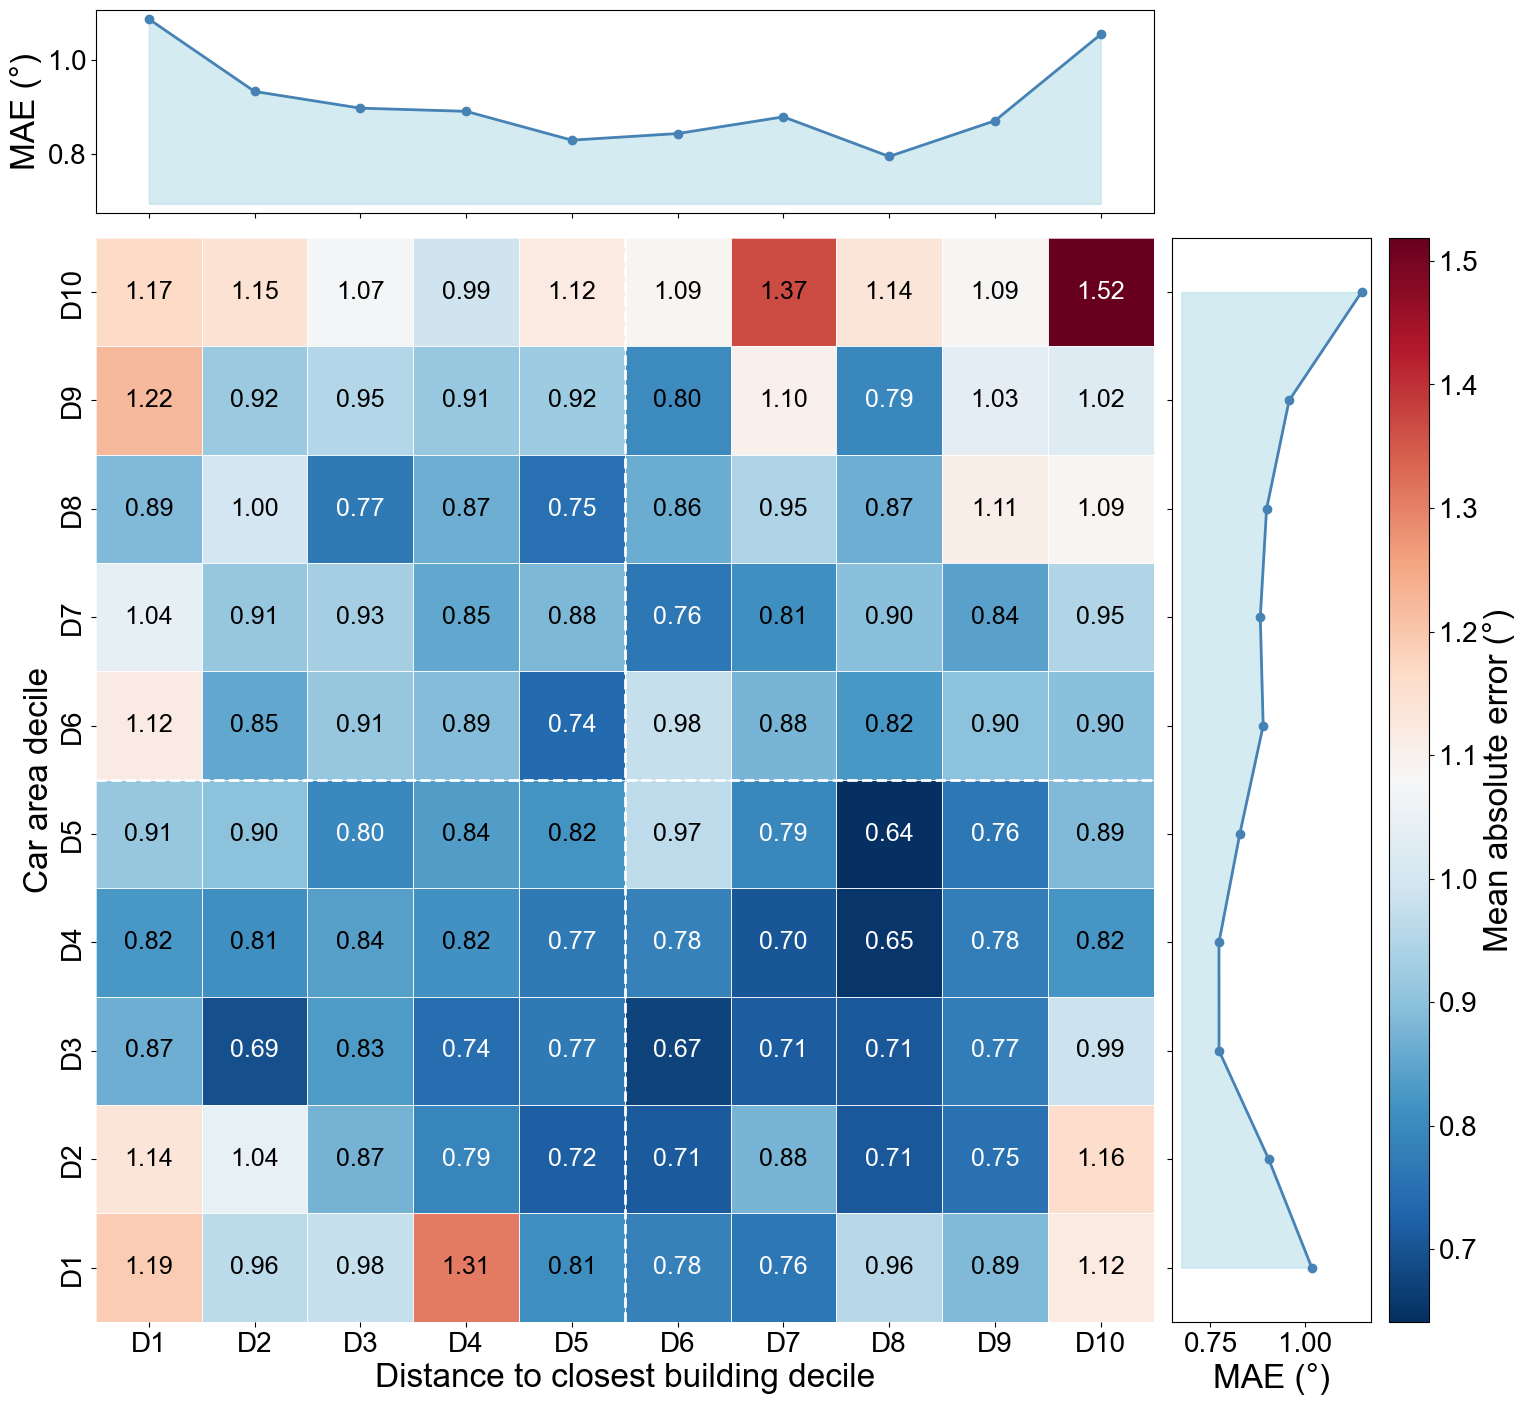

In [12]:
# count the number of samples in each cell
count_data = area_error_df.pivot_table(index='car_area_quantile', columns='distance_closest_building_quantile', values='abs_slope_diff_huber', aggfunc='count')
heatmap_data = area_error_df.pivot_table(index='car_area_quantile', columns='distance_closest_building_quantile', values='abs_slope_diff_huber', aggfunc='mean')
# if the count<3, set the heatmap value to NaN
heatmap_data[count_data < 3] = np.nan

# Create figure with subplots for main heatmap and marginal plots
fig = plt.figure(figsize=(20, 20))
gs = fig.add_gridspec(3, 4, width_ratios=[1.5, 8, 1.5, 0.3], height_ratios=[1.5, 8, 1.5], 
                      hspace=0.05, wspace=0.05)

# Main heatmap
ax_main = fig.add_subplot(gs[1, 1])
im = sns.heatmap(heatmap_data, annot=False, fmt=".2f", cmap='RdBu_r', cbar=False, ax=ax_main)

ax_main.set_xlabel('Distance to closest building decile', fontsize=label_fontsize)
ax_main.set_ylabel('Car area decile', fontsize=label_fontsize)
ax_main.tick_params(axis='both', labelsize=tick_fontsize)

# set text annotations for each cell
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data.iloc[i, j]
        count = count_data.iloc[i, j]
        if not np.isnan(value):
            ax_main.text(j + 0.5, i + 0.5, f"{value:.2f}", 
                         ha='center', va='center', color=text_color(value), fontsize=annotation_fontsize)

# reverse the y axis to have D1 at the bottom
ax_main.invert_yaxis()

# each cell add the white border
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        rect = plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='white', lw=0.5)
        ax_main.add_patch(rect)

# Colorbar in the dedicated space
cbar_ax = fig.add_subplot(gs[1, 3])
cbar = fig.colorbar(im.get_children()[0], cax=cbar_ax, orientation='vertical')
cbar.ax.tick_params(labelsize=tick_fontsize)
cbar.set_label('Mean absolute error (°)', fontsize=label_fontsize)

# add separation lines
ax_main.axhline(5, color='white', linewidth=2, linestyle='--')
ax_main.axvline(5, color='white', linewidth=2, linestyle='--')

# Top marginal plot
ax_top = fig.add_subplot(gs[0, 1], sharex=ax_main)
dist_medians = area_error_df.groupby('distance_closest_building_quantile')['abs_slope_diff_huber'].mean()

# Check if we have data and handle missing quantiles
if len(dist_medians) > 0:
    # Ensure we have data for all quantiles and handle missing ones
    dist_x_positions = range(len(dist_medians))
    # for each position, add 0.5 to center the marker in the cell
    dist_x_positions = [x + 0.5 for x in dist_x_positions]
    
    ax_top.plot(dist_x_positions, dist_medians.values, 
               color='steelblue', linewidth=2, marker='o', markersize=6)
    
    # Use robust min calculation for fill_between
    y_min = max(0, dist_medians.min() - 0.1)
    ax_top.fill_between(dist_x_positions, 
                       [y_min]*len(dist_medians), 
                       dist_medians.values, 
                       color='lightblue', alpha=0.5)

ax_top.tick_params(axis='x', labelbottom=False)
ax_top.tick_params(axis='y', labelsize=tick_fontsize)
ax_top.set_ylabel('MAE (°)', fontsize=label_fontsize)

# Right marginal plot
ax_right = fig.add_subplot(gs[1, 2], sharey=ax_main)
car_area_medians = area_error_df.groupby('car_area_quantile')['abs_slope_diff_huber'].mean()

# Check if we have data
if len(car_area_medians) > 0:
    # Reverse the order to match inverted y-axis
    car_area_y_positions = range(len(car_area_medians))
    car_area_y_positions = [y + 0.5 for y in car_area_y_positions]

    ax_right.plot(car_area_medians.values, car_area_y_positions,
                 color='steelblue', linewidth=2, marker='o', markersize=6)
    
    # Use robust min calculation for fill_betweenx
    x_min = max(0, min(car_area_medians.values) - 0.1)
    ax_right.fill_betweenx(car_area_y_positions, 
                          [x_min]*len(car_area_medians), 
                          car_area_medians.values, 
                          color='lightblue', alpha=0.5)

ax_right.tick_params(axis='y', labelleft=False)
ax_right.tick_params(axis='x', labelsize=tick_fontsize)
ax_right.set_xlabel('MAE (°)', fontsize=label_fontsize)

plt.tight_layout()
plt.show()

/var/folders/7_/kysgxgvn5h3680yrj7dky38w0000gn/T/ipykernel_31500/1020593355.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  count_data = area_error_df.pivot_table(index='road_area_quantile', columns='distance_closest_building_quantile', values='abs_slope_diff_huber', aggfunc='count')
/var/folders/7_/kysgxgvn5h3680yrj7dky38w0000gn/T/ipykernel_31500/1020593355.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = area_error_df.pivot_table(index='road_area_quantile', columns='distance_closest_building_quantile', values='abs_slope_diff_huber', aggfunc='mean')
/var/folders/7_/kysgxgvn5h3680yrj7dky38w0000gn/T/ipykernel_31500/1020593355.py:50: FutureWarn

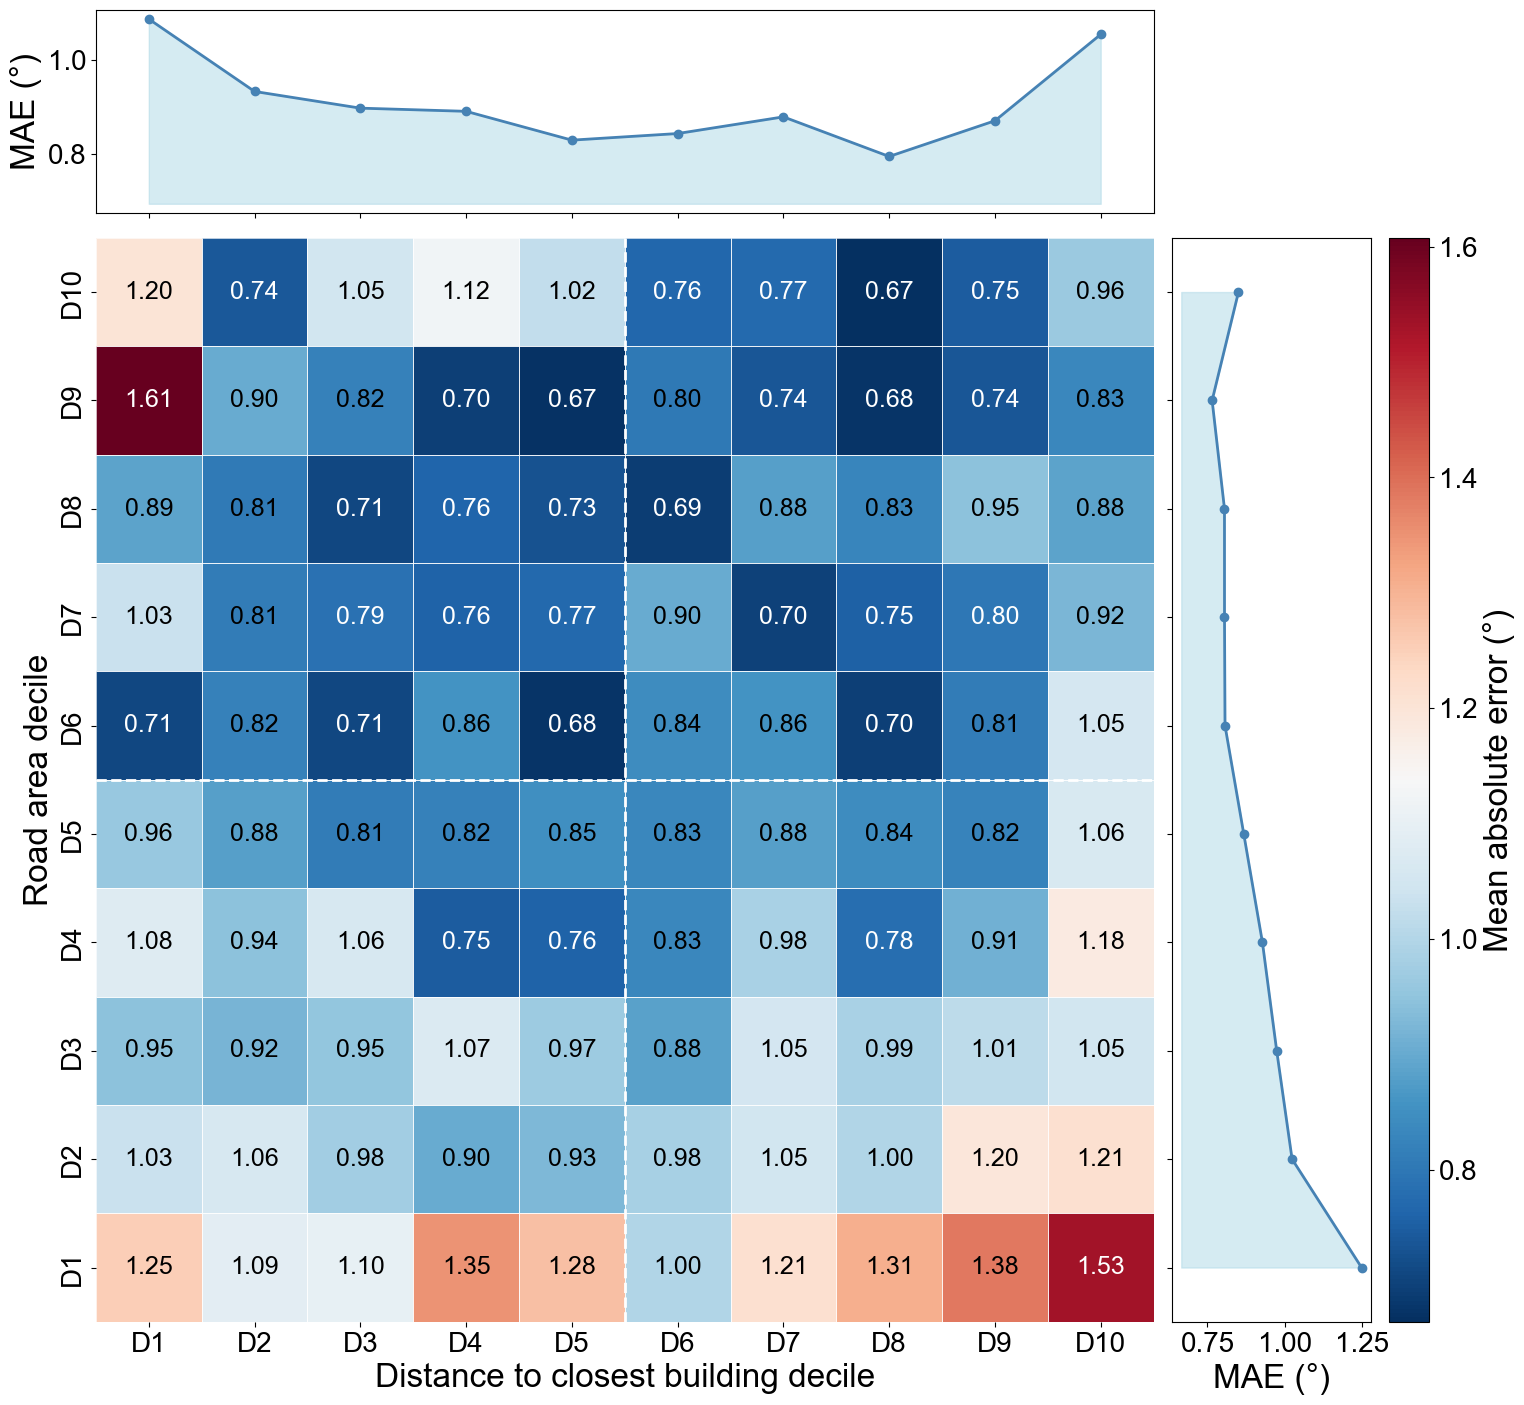

In [13]:
# count the number of samples in each cell
count_data = area_error_df.pivot_table(index='road_area_quantile', columns='distance_closest_building_quantile', values='abs_slope_diff_huber', aggfunc='count')
heatmap_data = area_error_df.pivot_table(index='road_area_quantile', columns='distance_closest_building_quantile', values='abs_slope_diff_huber', aggfunc='mean')
# if the count<3, set the heatmap value to NaN
heatmap_data[count_data < 3] = np.nan

# Create figure with subplots for main heatmap and marginal plots
fig = plt.figure(figsize=(20, 20))
gs = fig.add_gridspec(3, 4, width_ratios=[1.5, 8, 1.5, 0.3], height_ratios=[1.5, 8, 1.5], 
                      hspace=0.05, wspace=0.05)

# Main heatmap
ax_main = fig.add_subplot(gs[1, 1])
im = sns.heatmap(heatmap_data, annot=False, fmt=".2f", cmap='RdBu_r', cbar=False, ax=ax_main)

ax_main.set_xlabel('Distance to closest building decile', fontsize=label_fontsize)
ax_main.set_ylabel('Road area decile', fontsize=label_fontsize)
ax_main.tick_params(axis='both', labelsize=tick_fontsize)

# set text annotations for each cell
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data.iloc[i, j]
        count = count_data.iloc[i, j]
        if not np.isnan(value):
            ax_main.text(j + 0.5, i + 0.5, f"{value:.2f}", 
                         ha='center', va='center', color=text_color(value), fontsize=annotation_fontsize)

# reverse the y axis to have D1 at the bottom
ax_main.invert_yaxis()

# each cell add the white border
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        rect = plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='white', lw=0.5)
        ax_main.add_patch(rect)

# Colorbar in the dedicated space
cbar_ax = fig.add_subplot(gs[1, 3])
cbar = fig.colorbar(im.get_children()[0], cax=cbar_ax, orientation='vertical')
cbar.ax.tick_params(labelsize=tick_fontsize)
cbar.set_label('Mean absolute error (°)', fontsize=label_fontsize)

# add separation lines
ax_main.axhline(5, color='white', linewidth=2, linestyle='--')
ax_main.axvline(5, color='white', linewidth=2, linestyle='--')

# Top marginal plot
ax_top = fig.add_subplot(gs[0, 1], sharex=ax_main)
dist_medians = area_error_df.groupby('distance_closest_building_quantile')['abs_slope_diff_huber'].mean()

# Check if we have data and handle missing quantiles
if len(dist_medians) > 0:
    # Ensure we have data for all quantiles and handle missing ones
    dist_x_positions = range(len(dist_medians))
    # for each position, add 0.5 to center the marker in the cell
    dist_x_positions = [x + 0.5 for x in dist_x_positions]
    
    ax_top.plot(dist_x_positions, dist_medians.values, 
               color='steelblue', linewidth=2, marker='o', markersize=6)
    
    # Use robust min calculation for fill_between
    y_min = max(0, dist_medians.min() - 0.1)
    ax_top.fill_between(dist_x_positions, 
                       [y_min]*len(dist_medians), 
                       dist_medians.values, 
                       color='lightblue', alpha=0.5)

ax_top.tick_params(axis='x', labelbottom=False)
ax_top.tick_params(axis='y', labelsize=tick_fontsize)
ax_top.set_ylabel('MAE (°)', fontsize=label_fontsize)

# Right marginal plot
ax_right = fig.add_subplot(gs[1, 2], sharey=ax_main)
road_area_medians = area_error_df.groupby('road_area_quantile')['abs_slope_diff_huber'].mean()

# Check if we have data
if len(road_area_medians) > 0:
    # Reverse the order to match inverted y-axis
    road_area_y_positions = range(len(road_area_medians))
    road_area_y_positions = [y + 0.5 for y in road_area_y_positions]

    ax_right.plot(road_area_medians.values, road_area_y_positions,
                 color='steelblue', linewidth=2, marker='o', markersize=6)
    
    # Use robust min calculation for fill_betweenx
    x_min = max(0, min(road_area_medians.values) - 0.1)
    ax_right.fill_betweenx(road_area_y_positions, 
                          [x_min]*len(road_area_medians), 
                          road_area_medians.values, 
                          color='lightblue', alpha=0.5)

ax_right.tick_params(axis='y', labelleft=False)
ax_right.tick_params(axis='x', labelsize=tick_fontsize)
ax_right.set_xlabel('MAE (°)', fontsize=label_fontsize)

plt.tight_layout()
plt.show()